# 02 — Regime Detection & Regime-Specific Training

The baseline notebook trained one LSTM on the whole price history. The idea here is that
markets don't behave the same way all the time — a trending market and a choppy, range-bound
market have different statistical properties, and a single model has to compromise between them.

This notebook:
1. Classifies every day into one of four regimes: **uptrend, downtrend, high_volatility,
   sideways**.
2. Trains a separate model for each regime, using an architecture suited to that regime's
   dynamics.
3. Handles the practical problem that some regimes have far less data than others (volatility
   spikes are rare) without just overfitting a big model to 100 rows.

**Input:** `data/processed/NVDA_features.csv` directly — the same canonical dataset notebook 1
uses. No intermediate `featured_data.csv` is read or written.
**Output:** one weights file per trained model in `models/`, and `reports/regime_results.pkl`
(every model's training history and test predictions), consumed by the plotting notebook.


In [15]:
import warnings
warnings.filterwarnings("ignore")

import os
import pickle
from copy import deepcopy
from dataclasses import dataclass

import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# ============================================================================
# Constants — everything that configures this notebook lives here.
# ============================================================================
DATA_PATH   = "data/processed/NVDA_features.csv"   # canonical engineered-feature CSV
MODELS_DIR  = "models"                              # trained model weights go here
REPORTS_DIR = "reports"                             # figures / summaries / results go here

FINAL_HEADER = (
    "date,open,high,low,close,volume,return_1,return_5,log_return_1,sma_20,sma_50,"
    "sma_200,sma_ratio_20,sma_ratio_50,ema_12,ema_20,ema_26,ema_ratio_20,rsi_14,macd,"
    "macd_signal,macd_hist,bb_upper,bb_lower,bb_width,bb_pct_b,roc_5,roc_10,atr_14,"
    "atr_ratio,stoch_k,stoch_d,obv,obv_change,vwap,vwap_ratio,z_score_20,future_return,"
    "target_direction"
).split(",")

REGIMES = ["uptrend", "downtrend", "high_volatility", "sideways"]
REGIME_MODEL_MAP = {
    "uptrend":         "lstm",
    "downtrend":       "lstm",
    "high_volatility": "gru",
    "sideways":        "bilstm",
}
REGIME_COLORS = {
    "uptrend": "#2ecc71", "downtrend": "#e74c3c",
    "high_volatility": "#f39c12", "sideways": "#95a5a6",
}

FEATURE_COLUMNS = [
    "return_1", "return_5", "log_return_1",
    "sma_ratio_20", "sma_ratio_50", "ema_ratio_20",
    "rsi_14", "macd", "macd_signal", "macd_hist",
    "bb_width", "bb_pct_b",
    "roc_5", "roc_10",
    "atr_ratio",
    "stoch_k", "stoch_d",
    "obv_change",
    "vwap_ratio",
    "z_score_20",
]

SEQUENCE_LENGTH = 5
TRAIN_SPLIT     = 0.80
VAL_FRACTION    = 0.15
MIN_SAMPLES     = 400   # regimes below this are skipped entirely (too little signal to train on)
CV_THRESHOLD    = 50   # regimes below this use 5-fold CV instead of a single train/val split
SMALL_THRESHOLD = 150   # regimes below this never unfreeze a transferred recurrent stack
SEED            = 42

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)

# Dark background theme for every figure produced in this notebook.
plt.style.use("dark_background")
plt.rcParams.update({
    "figure.facecolor":  "#0d1117",
    "axes.facecolor":    "#0d1117",
    "savefig.facecolor": "#0d1117",
    "axes.grid": True,
    "grid.alpha": 0.25,
})

torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


Using device: cpu


## 1. Load the engineered feature set

Reads directly from `data/processed/NVDA_features.csv` — the same file notebook 1 uses. No
intermediate `featured_data.csv` is involved. If any indicator column is missing, the same
`calculate_indicators()` logic from notebook 1 is used to compute it, and the result is appended
back into `DATA_PATH` (re-run notebook 1 first if this branch triggers and the function isn't
defined in this session).


In [16]:
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"{DATA_PATH} not found — place the engineered CSV there first.")

raw = pd.read_csv(DATA_PATH)

if set(FINAL_HEADER).issubset(raw.columns):
    df = raw[FINAL_HEADER].copy()
    print(f"Loaded engineered features directly from {DATA_PATH}")
else:
    print("Some indicator columns are missing — computing them and appending to DATA_PATH.")
    df = calculate_indicators(raw[["date", "open", "high", "low", "close", "volume"]])
    df = df[FINAL_HEADER]
    df.to_csv(DATA_PATH, index=False)
    print(f"Appended newly computed indicator columns to {DATA_PATH}")

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)
df = df.dropna().reset_index(drop=True)
print(f"{len(df)} rows | {df['date'].min().date()} -> {df['date'].max().date()}")
df.head()


Loaded engineered features directly from data/processed/NVDA_features.csv
2623 rows | 2015-12-28 -> 2026-06-03


,date,open,high,low,close,volume,return_1,return_5,log_return_1,sma_20,...,atr_ratio,stoch_k,stoch_d,obv,obv_change,vwap,vwap_ratio,z_score_20,future_return,target_direction
0,2015-12-28,0.82050,0.82850,0.80900,0.82850,142024000.0,-0.000904,0.031114,-0.000905,0.820900,...,0.020821,0.630302,0.613397,3.068132e+09,-0.044242,0.604484,0.370591,0.654351,0.016295,1
1,2015-12-29,0.82900,0.84450,0.82675,0.84200,203660000.0,0.016295,0.023708,0.016163,0.823350,...,0.019427,0.940476,0.739754,3.271792e+09,0.066379,0.605198,0.391280,1.769845,-0.008610,0
2,2015-12-30,0.84125,0.84850,0.83450,0.83475,180344000.0,-0.008610,0.013969,-0.008648,0.824150,...,0.017841,0.701087,0.757288,3.091448e+09,-0.055121,0.605831,0.377859,0.983784,-0.012878,0
3,2015-12-31,0.83350,0.83725,0.82400,0.82400,148528000.0,-0.012878,-0.003025,-0.012962,0.824725,...,0.018226,0.467391,0.702985,2.942920e+09,-0.048045,0.606326,0.359004,-0.069568,-0.017900,0
4,2016-01-04,0.80725,0.81450,0.80100,0.80925,358076000.0,-0.017900,-0.024118,-0.018063,0.824650,...,0.019352,0.173684,0.447387,2.584844e+09,-0.121674,0.607403,0.332312,-1.462206,0.016064,1


## 2. Regime classification

Every row in the dataset gets labelled with one of four market regimes: `uptrend`, `downtrend`, `high_volatility`, or `sideways`. This label drives which specialist model receives the sample at inference time.

**Your task — implement `classify_regimes(df, vol_quantile, smooth_window)`:**

The logic should follow these steps **in order**:

1. **Volatility flag** — Compute a 10-day rolling std of `return_1` as `realized_vol`. Mark days above the `vol_quantile` percentile of that series as `high_vol_flag = True`.

2. **Trend signal** — Compute an adaptive threshold as `0.5 × std(sma_ratio_50)`. Assign `"uptrend"` where `sma_ratio_50 > threshold` and `"downtrend"` where it is below `−threshold`; everything else is `"sideways"`.

3. **MACD confirmation** — Demote `"uptrend"` days where `macd < 0` to `"sideways"`, and `"downtrend"` days where `macd > 0` to `"sideways"`. (A trend without MACD confirmation is treated as noise.)

4. **High-volatility overlay** — Upgrade `"sideways"` days that also have `high_vol_flag = True` to `"high_volatility"`.

5. **Smoothing** — Apply a `smooth_window`-day rolling majority vote (centre-aligned, `min_periods=1`) to the integer-encoded regime labels using `np.bincount(...).argmax()`. Decode back to string labels and store in `df["market_regime"]`.

Return the augmented DataFrame.


In [17]:
def classify_regimes(df: pd.DataFrame, vol_quantile: float = 0.75,
                      smooth_window: int = 5) -> pd.DataFrame:
    """
    Label every row with a market regime:
        uptrend | downtrend | high_volatility | sideways

    Steps:
      1. Compute realized_vol (10-day rolling std of return_1) and high_vol_flag.
      2. Derive trend label from sma_ratio_50 using an adaptive threshold.
      3. Apply MACD confirmation to filter weak trend signals back to sideways.
      4. Overlay high_volatility on sideways days that also exceed vol_quantile.
      5. Smooth with a rolling majority vote (smooth_window, centre-aligned).
    """
    df = df.copy()

    # TODO 1: compute realized_vol = 10-day rolling std of return_1 (bfill NaNs)
    #         compute vol_threshold = realized_vol.quantile(vol_quantile)
    #         set high_vol_flag = realized_vol >= vol_threshold
    pass
    realized_vol = df["return_1"].rolling(10).std().bfill()
    vol_threshold = realized_vol.quantile(vol_quantile)
    high_vol_flag = realized_vol >= vol_threshold

    # TODO 2: compute trend_threshold = df["sma_ratio_50"].std() * 0.5
    #         initialise a pd.Series called trend filled with "sideways"
    #         assign "uptrend"   where sma_ratio_50 >  trend_threshold
    #         assign "downtrend" where sma_ratio_50 < -trend_threshold
    pass
    trend_threshold = df["sma_ratio_50"].std() * 0.5
    trend = pd.Series("sideways", index=df.index)
    trend[df["sma_ratio_50"] > trend_threshold] = "uptrend"
    trend[df["sma_ratio_50"] < -trend_threshold] = "downtrend"
    # TODO 3: demote "uptrend" rows where macd < 0 → "sideways"
    #         demote "downtrend" rows where macd > 0 → "sideways"
    pass
    trend[(trend == "uptrend") & (df["macd"] < 0)] = "sideways"
    trend[(trend == "downtrend") & (df["macd"] > 0)] = "sideways"
    # TODO 4: start with regime = trend.copy()
    #         upgrade "sideways" & high_vol_flag rows to "high_volatility"
    pass
    regime = trend.copy()
    regime[(regime == "sideways") & high_vol_flag] = "high_volatility"
    # TODO 5: factorize regime to integer codes, apply rolling majority vote
    #         (smooth_window, center=True, min_periods=1, .apply(bincount argmax))
    #         decode back to strings and store in df["market_regime"]
    pass
    codes, uniques = pd.factorize(regime)
    smoothed_codes = pd.Series(codes).rolling(
        smooth_window, center=True, min_periods=1
    ).apply(lambda x: np.bincount(x.astype(int)).argmax())
    df["market_regime"] = uniques[smoothed_codes.astype(int)]
    return df


df = classify_regimes(df)

print("Regime distribution:")
regime_counts = {}
for r in REGIMES:
    n = int((df["market_regime"] == r).sum())
    regime_counts[r] = n
    print(f"  {r:18s}: {n:5d} rows ({100*n/len(df):.1f}%)")


Regime distribution:
  uptrend           :  1345 rows (51.3%)
  downtrend         :   389 rows (14.8%)
  high_volatility   :   146 rows (5.6%)
  sideways          :   743 rows (28.3%)


### Regime frequency

A quick sanity check before training anything regime-specific: how many days actually fall
into each regime. A regime with very few days (see `MIN_SAMPLES` in the constants cell) gets
skipped entirely in Section 7 rather than trained on too little signal.


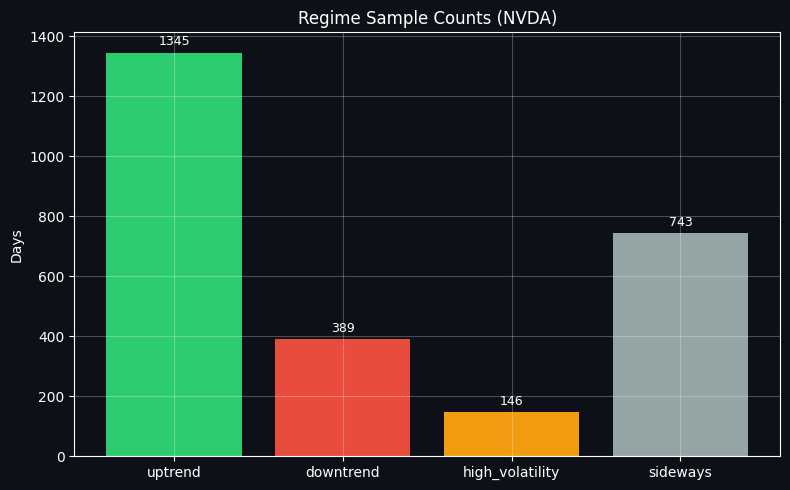

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(regime_counts.keys(), regime_counts.values(),
              color=[REGIME_COLORS[r] for r in regime_counts])
for bar, r in zip(bars, regime_counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(regime_counts.values()) * 0.01,
            str(regime_counts[r]), ha="center", va="bottom", fontsize=9)
ax.set_title("Regime Sample Counts (NVDA)")
ax.set_ylabel("Days")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/fig_regime_counts.png", dpi=140)
plt.show()


## 3. Architecture per regime, and why

| Regime | Model | Reasoning |
|---|---|---|
| `uptrend` / `downtrend` | **LSTM** | Full cell-state memory carries a sustained directional signal across the window — the natural fit for momentum/trend-following dynamics. |
| `high_volatility` | **GRU** | Fewer gates, no separate cell state — adapts faster when conditions are changing quickly, and has fewer parameters to overfit on what's usually the smallest regime by sample count. |
| `sideways` | **BiLSTM** | Bidirectional *only within the fixed 20-day input window* (never into the actual future — still fully causal at prediction time). This lets it relate early-window days to late-window days in both directions while encoding, which helps recognise range-bound bounce/reversion patterns. |

Smaller regimes get smaller, more regularised models — a 64-hidden 2-layer network has more
than enough capacity to memorise a 100-row regime instead of learning anything generalisable
from it. (`REGIME_MODEL_MAP` is defined in the constants cell above.)


In [19]:
@dataclass
class RegimeConfig:
    epochs: int = 4
    batch_size: int = 64
    learning_rate: float = 0.08
    weight_decay: float = 1e-3
    grad_clip: float = 1.0
    patience: int = 10
    lambda_dir: float = 0.30
    hidden_size: int = 64
    num_layers: int = 2
    dropout: float = 0.4
    model_type: str = "lstm"


def regime_config(regime: str) -> RegimeConfig:
    presets = {
        "high_volatility": RegimeConfig(hidden_size=4, num_layers=1, dropout=0.50,
                                         patience=15, lambda_dir=0.40, model_type="gru"),
        "downtrend":       RegimeConfig(hidden_size=4, num_layers=2, dropout=0.45,
                                         patience=12, lambda_dir=0.35, model_type="lstm"),
        "uptrend":         RegimeConfig(hidden_size=4, num_layers=2, dropout=0.40,
                                         patience=10, lambda_dir=0.30, model_type="lstm"),
        "sideways":        RegimeConfig(hidden_size=4, num_layers=2, dropout=0.40,
                                         patience=10, lambda_dir=0.30, model_type="bilstm"),
        "base":            RegimeConfig(hidden_size=4, num_layers=2, dropout=0.40,
                                         patience=10, lambda_dir=0.25, model_type="lstm"),
    }
    return presets.get(regime, presets["base"])


## 4. Model, loss, and core training functions

Same architecture as notebook 1 — re-defined here so this notebook runs independently.

**Your tasks (same as notebook 1 — implement each `# TODO` block):**

1. **`TemporalAttention.forward(lstm_out)`** — Apply `self.scorer` across the time axis, softmax over `dim=1`, return the weighted sum of `lstm_out` along `dim=1`.

2. **`ReturnSequenceModel.forward(x)`** — Run `self.recurrent`, pass the full output through `self.attention`, then through `self.head`. Squeeze the last dimension before returning.

3. **`DirectionWeightedLoss.forward(pred, target)`** — Build per-sample weights (`up_weight` / `down_weight`). Return the sum of the weighted Huber term and `lambda_dir × weighted BCE` (use `binary_cross_entropy_with_logits` with `temp`-scaled logits).

4. **`make_sequences(features, targets, seq_len)`** — Build overlapping `(X, y)` windows of length `seq_len`, return as `float32` arrays.

5. **`winsorise(arr, n_std=3.0)`** — Clip `arr` symmetrically at `±(n_std × arr.std())`.


In [20]:
class TemporalAttention(nn.Module):
    def __init__(self, hidden_size: int) -> None:
        super().__init__()
        self.scorer = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, lstm_out: torch.Tensor) -> torch.Tensor:
        # TODO: score each timestep with self.scorer (batch, seq_len, 1)
        # TODO: softmax over dim=1 to get attention weights
        # TODO: return weighted sum of lstm_out along dim=1 → (batch, hidden)
        pass
        scores = self.scorer(lstm_out)
        weights = torch.softmax(scores, dim=1)
        return (weights * lstm_out).sum(dim=1)


class ReturnSequenceModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.4, model_type="lstm"):
        super().__init__()
        model_type = model_type.lower()
        bidirectional = model_type == "bilstm"
        recurrent_cls = nn.GRU if model_type == "gru" else nn.LSTM
        self.recurrent = recurrent_cls(
            input_size=input_size, hidden_size=hidden_size, num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True, bidirectional=bidirectional,
        )
        out_dim = hidden_size * (2 if bidirectional else 1)
        self.attention = TemporalAttention(out_dim)
        self.head = nn.Sequential(
            nn.LayerNorm(out_dim), nn.Linear(out_dim, 64), nn.GELU(),
            nn.Dropout(dropout * 0.5), nn.Linear(64, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO: pass x through self.recurrent, unpack to get out (all hidden states)
        # TODO: pass out through self.attention to get context vector
        # TODO: pass context through self.head and squeeze the last dimension
        pass
        out, _ = self.recurrent(x)
        context = self.attention(out)
        return self.head(context).squeeze(-1)


class DirectionWeightedLoss(nn.Module):
    def __init__(self, up_weight=1.0, down_weight=1.0, lambda_dir=0.30, temp=50.0):
        super().__init__()
        self.up_weight, self.down_weight = up_weight, down_weight
        self.lambda_dir, self.temp = lambda_dir, temp
        self.huber = nn.SmoothL1Loss(reduction="none")

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        # TODO: build weight tensor w (up_weight where target > 0, else down_weight)
        # TODO: weighted_huber = mean of huber(pred, target) * w
        # TODO: dir_target = (target > 0).float()
        # TODO: bce per-sample = binary_cross_entropy_with_logits(pred*self.temp, dir_target, reduction="none")
        # TODO: weighted_bce = mean of bce * w, scaled by self.lambda_dir
        # TODO: return weighted_huber + weighted_bce
        pass
        w = torch.where(target > 0, self.up_weight, self.down_weight)
        weighted_huber = (self.huber(pred, target) * w).mean()
        dir_target = (target > 0).float()
        bce = torch.nn.functional.binary_cross_entropy_with_logits(
            pred * self.temp, dir_target, reduction="none")
        weighted_bce = self.lambda_dir * (bce * w).mean()
        return weighted_huber + weighted_bce
        


def compute_class_weights(y_train):
    n      = len(y_train)
    n_up   = max((y_train > 0).sum(), 1)
    n_down = max((y_train <= 0).sum(), 1)
    return float(n / (2.0 * n_up)), float(n / (2.0 * n_down))


def make_sequences(features: np.ndarray, targets: np.ndarray, seq_len: int):
    """
    Build (X, y) pairs: for each i in [seq_len, len(features)),
    X[i] = features[i - seq_len : i], y[i] = targets[i].
    Return two float32 arrays of shapes (N, seq_len, n_features) and (N,).
    """
    # TODO: loop over valid indices, collect windows, convert to float32 numpy arrays
    pass
    xs, ys = [], []
    for i in range(seq_len, len(features)):
        xs.append(features[i - seq_len:i])
        ys.append(targets[i])
    return np.array(xs, dtype=np.float32), np.array(ys, dtype=np.float32)


def winsorise(arr: np.ndarray, n_std: float = 3.0) -> np.ndarray:
    """Clip arr symmetrically at ±(n_std * arr.std())."""
    # TODO: compute lo, hi bounds and return np.clip(arr, lo, hi)
    pass
    std = arr.std()
    lo, hi = -n_std * std, n_std * std
    return np.clip(arr, lo, hi)


## 5. Handling small regimes: transfer learning + k-fold CV

Some regimes (notably `high_volatility`) may have far fewer training samples than others. Two strategies compensate:

**Your tasks:**

1. **`transfer_from_base(model, base_model, freeze_recurrent=True)`** — Copy weights from `base_model` into `model` for every layer whose name does **not** contain `"head"` and whose tensor shape matches. After copying, if `freeze_recurrent=True`, call `p.requires_grad_(False)` for every parameter whose name does not contain `"head"`. Return the updated model.

2. **`kfold_train(x_train, y_train, config, n_splits=5)`** — Perform k-fold cross-validation (do **not** shuffle the folds — this is time-series data). For each fold:
   - Build a fresh `ReturnSequenceModel` and `DirectionWeightedLoss` using `config`.
   - Run a full training loop with early stopping (same structure as `train_regime_model`).
   - After training, evaluate direction accuracy on the fold's validation split.
   
   Return a dict `{"cv_dir_acc": float, "cv_dir_std": float}` summarising the mean and std of fold accuracies.

`unfreeze_all` is already implemented — call it when you need to unfreeze all parameters of a model.


In [21]:
def transfer_from_base(model, base_model, freeze_recurrent=True):
    """
    Copy compatible weights from base_model into model, skipping the prediction head.
    If freeze_recurrent=True, freeze all non-head parameters after copying.
    """
    base_sd, model_sd = base_model.state_dict(), model.state_dict()
    # TODO: iterate base_sd.items(); for keys not containing "head" that exist in model_sd
    #       with matching shapes, copy v.clone() into model_sd[k]
    # TODO: load the updated model_sd back into model
    # TODO: if freeze_recurrent: for each named parameter not containing "head",
    #       call p.requires_grad_(False)
    pass
    for k, v in base_sd.items():
        if "head" not in k and k in model_sd and model_sd[k].shape == v.shape:
            model_sd[k] = v.clone()
    model.load_state_dict(model_sd)
    if freeze_recurrent:
        for name, p in model.named_parameters():
            if "head" not in name:
                p.requires_grad_(False)
    return model


def unfreeze_all(model):
    for p in model.parameters():
        p.requires_grad_(True)


def kfold_train(x_train, y_train, config, n_splits=5):
    """
    Time-series k-fold cross-validation (shuffle=False).
    Returns {"cv_dir_acc": float, "cv_dir_std": float}.
    """
    kf = KFold(n_splits=n_splits, shuffle=False)
    fold_metrics = []

    for tr_idx, val_idx in kf.split(x_train):
        xf_tr, yf_tr   = x_train[tr_idx], y_train[tr_idx]
        xf_val, yf_val = x_train[val_idx], y_train[val_idx]

        # TODO: compute class weights and build DirectionWeightedLoss
        # TODO: build ReturnSequenceModel and move to DEVICE
        # TODO: build DataLoader (batch_size = max(16, config.batch_size // 2), shuffle=True)
        # TODO: build AdamW optimizer and ReduceLROnPlateau scheduler

        # TODO: run training loop for config.epochs with early stopping on val loss:
        #       - for each batch: zero_grad → forward → loss → backward → clip_grad_norm_ → step
        #       - eval on xf_val after each epoch, scheduler.step(val_loss)
        #       - track best_state (deepcopy), patience counter, break at config.patience
        # TODO: restore best_state if found

        # TODO: evaluate direction accuracy on xf_val and append to fold_metrics
        pass
        
        w_up, w_down = compute_class_weights(yf_tr)
        loss_fn = DirectionWeightedLoss(up_weight=w_up, down_weight=w_down,
                                         lambda_dir=config.lambda_dir)
        model = ReturnSequenceModel(input_size=xf_tr.shape[-1], hidden_size=config.hidden_size,
                                     num_layers=config.num_layers, dropout=config.dropout,
                                     model_type=config.model_type).to(DEVICE)
        loader = DataLoader(TensorDataset(torch.tensor(xf_tr), torch.tensor(yf_tr)),
                             batch_size=max(16, config.batch_size // 2), shuffle=True)
        optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate,
                                       weight_decay=config.weight_decay)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=5, min_lr=config.learning_rate * 0.02)

        best_val, best_state, patience_ctr = float("inf"), None, 0
        for epoch in range(config.epochs):
            model.train()
            for bx, by in loader:
                bx, by = bx.to(DEVICE), by.to(DEVICE)
                optimizer.zero_grad()
                loss = loss_fn(model(bx), by)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), config.grad_clip)
                optimizer.step()

            model.eval()
            with torch.no_grad():
                vp = model(torch.tensor(xf_val).to(DEVICE))
                vy = torch.tensor(yf_val).to(DEVICE)
                val_loss = float(loss_fn(vp, vy).item())
            scheduler.step(val_loss)

            if val_loss < best_val - 1e-6:
                best_val, best_state, patience_ctr = val_loss, deepcopy(model.state_dict()), 0
            else:
                patience_ctr += 1
            if patience_ctr >= config.patience:
                break

        if best_state:
            model.load_state_dict(best_state)

        model.eval()
        with torch.no_grad():
            val_preds = model(torch.tensor(xf_val).to(DEVICE)).cpu().numpy()
        fold_metrics.append(accuracy_score(yf_val > 0, val_preds > 0))

    return {"cv_dir_acc": float(np.mean(fold_metrics)), "cv_dir_std": float(np.std(fold_metrics))}


## 6. Main training function

`train_regime_model` ties everything together: data preparation, optional transfer learning, and the main epoch loop.

**Your task — complete the per-batch training step inside the epoch loop:**

Each iteration over `loader` yields `(bx, by)`. For each batch you must:
1. Move `bx` and `by` to `DEVICE`.
2. Zero the optimizer's gradients.
3. Forward-pass through `model`, compute `loss_fn(output, by)`.
4. Call `.backward()`.
5. Clip gradients with `nn.utils.clip_grad_norm_(model.parameters(), config.grad_clip)`.
6. Call `optimizer.step()`.
7. Append `loss.item()` to `ep_losses`.

Everything else — data splitting, scaler reuse, class weights, transfer-learning phases, the validation loop, early stopping, and metric collection — is already written for you.


In [22]:
def train_regime_model(data, config, full_train_scaler, regime="base",
                        base_model=None, verbose=True):
    data = data.sort_values("date").reset_index(drop=True)
    split_idx = int(len(data) * TRAIN_SPLIT)
    val_size  = max(int(split_idx * VAL_FRACTION), 1)
    train_end = split_idx - val_size

    scaler = full_train_scaler if full_train_scaler is not None else StandardScaler().fit(
        data.iloc[:train_end][FEATURE_COLUMNS])
    all_feats = scaler.transform(data[FEATURE_COLUMNS])
    raw_tgts  = data["future_return"].to_numpy(dtype=np.float32)
    train_tgts = winsorise(raw_tgts[:train_end])
    targets   = np.concatenate([train_tgts, raw_tgts[train_end:]])

    x_all, y_all = make_sequences(all_feats, targets, SEQUENCE_LENGTH)
    n_train = max(train_end - SEQUENCE_LENGTH, 1)
    n_val   = max(split_idx - SEQUENCE_LENGTH - n_train, 0)
    x_train, y_train = x_all[:n_train], y_all[:n_train]
    x_val,   y_val   = x_all[n_train:n_train+n_val], y_all[n_train:n_train+n_val]
    x_test,  y_test  = x_all[n_train+n_val:], y_all[n_train+n_val:]

    cv_result = None
    if n_train < CV_THRESHOLD and n_train >= 30:
        if verbose:
            print(f"    [kfold] n_train={n_train} < {CV_THRESHOLD} -> 5-fold CV")
        cv_result = kfold_train(x_train, y_train, config)
        if verbose:
            print(f"    [kfold] CV dir_acc = {cv_result['cv_dir_acc']:.3f} +/- {cv_result['cv_dir_std']:.3f}")

    w_up, w_down = compute_class_weights(y_train)
    loss_fn = DirectionWeightedLoss(up_weight=w_up, down_weight=w_down, lambda_dir=config.lambda_dir)
    model = ReturnSequenceModel(input_size=x_train.shape[-1], hidden_size=config.hidden_size,
                                 num_layers=config.num_layers, dropout=config.dropout,
                                 model_type=config.model_type).to(DEVICE)

    phase1_epochs = 0
    if base_model is not None and n_train < CV_THRESHOLD * 3:
        if verbose:
            print(f"    [transfer] copying recurrent+attention from base model, freezing")
        model = transfer_from_base(model, base_model, freeze_recurrent=True)
        if n_train < SMALL_THRESHOLD:
            if verbose:
                print(f"    [transfer] n_train={n_train} < {SMALL_THRESHOLD} -> stays frozen "
                      f"the whole run (head-only)")
        else:
            phase1_epochs = min(10, config.epochs // 4)

    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                                   lr=config.learning_rate, weight_decay=config.weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=5, min_lr=config.learning_rate * 0.02)
    loader = DataLoader(TensorDataset(torch.tensor(x_train), torch.tensor(y_train)),
                         batch_size=config.batch_size, shuffle=True)

    history = {"train_loss": [], "val_loss": [], "val_dir_acc": [], "lr": []}
    best_val, best_state, patience_ctr = float("inf"), None, 0
    best_acc, best_acc_epoch = -1.0, -1

    for epoch in range(config.epochs):
        if epoch == phase1_epochs and phase1_epochs > 0:
            unfreeze_all(model)
            optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate * 0.3,
                                           weight_decay=config.weight_decay)
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode="min", factor=0.5, patience=5, min_lr=config.learning_rate * 0.01)
            if verbose:
                print(f"    [transfer] phase 2 (epoch {epoch+1}): all layers unfrozen")

        model.train()
        ep_losses = []
        for bx, by in loader:
            # TODO: move bx and by to DEVICE
            # TODO: zero optimizer gradients
            # TODO: compute loss = loss_fn(model(bx), by)
            # TODO: loss.backward()
            # TODO: clip gradients: nn.utils.clip_grad_norm_(model.parameters(), config.grad_clip)
            # TODO: optimizer.step()
            # TODO: ep_losses.append(loss.item())
            pass
            bx, by = bx.to(DEVICE), by.to(DEVICE)
            optimizer.zero_grad()
            loss = loss_fn(model(bx), by)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), config.grad_clip)
            optimizer.step()
            ep_losses.append(loss.item())
        train_loss = float(np.mean(ep_losses))

        model.eval()
        with torch.no_grad():
            vp = model(torch.tensor(x_val).to(DEVICE))
            vy = torch.tensor(y_val).to(DEVICE)
            val_loss = float(loss_fn(vp, vy).item())
            val_preds = vp.cpu().numpy()
            val_acc = float(accuracy_score(y_val > 0, val_preds > 0))
        scheduler.step(val_loss)

        if val_loss < best_val - 1e-6:
            best_val, best_state, patience_ctr = val_loss, deepcopy(model.state_dict()), 0
        else:
            patience_ctr += 1
        if val_acc > best_acc:
            best_acc, best_acc_epoch = val_acc, epoch + 1
        if patience_ctr >= config.patience:
            if verbose:
                print(f"    Early stop @ epoch {epoch+1} (best val={best_val:.6f})")
            break

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_dir_acc"].append(val_acc)
        history["lr"].append(optimizer.param_groups[0]["lr"])

        if verbose and ((epoch + 1) % 10 == 0 or epoch == 0):
            print(f"    Epoch {epoch+1:03d}  train={train_loss:.6f}  val={val_loss:.6f}  "
                  f"dir_acc={val_acc:.3f}  lr={optimizer.param_groups[0]['lr']:.2e}")

    if best_state:
        model.load_state_dict(best_state)
    if verbose and best_acc_epoch > 0 and best_acc_epoch < len(history["val_loss"]) - 3:
        print(f"    [note] best val_dir_acc={best_acc:.3f} was at epoch {best_acc_epoch}, "
              f"deployed checkpoint is the lowest-val-loss one instead.")

    model.eval()
    with torch.no_grad():
        preds = model(torch.tensor(x_test).to(DEVICE)).cpu().numpy()
    metrics = {
        "test_rmse": float(np.sqrt(mean_squared_error(y_test, preds))),
        "test_mae": float(mean_absolute_error(y_test, preds)),
        "direction_accuracy": float(accuracy_score(y_test > 0, preds > 0)),
        "f1_score": float(f1_score(y_test > 0, preds > 0, zero_division=0)),
        "n_train": len(x_train), "n_val": len(x_val), "n_test": len(x_test),
        "y_test": y_test, "preds": preds,
    }
    return model, history, metrics, cv_result


## 7. Train the base model and every regime model

The full-dataset scaler is fit once and reused everywhere (including inside each regime's
training) — fitting a separate scaler on a 100-row regime slice would give it a distorted
sense of "normal" feature scale compared to what the model saw during transfer learning.


In [23]:
split_idx = int(len(df) * TRAIN_SPLIT)
full_scaler = StandardScaler().fit(df.iloc[:split_idx][FEATURE_COLUMNS])

all_histories, all_metrics, all_cv, all_models = {}, {}, {}, {}

print("[base] training on the full dataset...")
base_cfg = regime_config("base")
base_model, base_hist, base_metrics, _ = train_regime_model(
    df, base_cfg, full_scaler, regime="base")
all_histories["base_lstm"] = base_hist
all_metrics["base_lstm"]   = base_metrics
all_models["base_lstm"]    = base_model

for regime in REGIMES:
    model_type = REGIME_MODEL_MAP[regime]
    subset = df.loc[df["market_regime"] == regime].copy().reset_index(drop=True)
    print(f"\n[{regime}] {len(subset)} rows -> {model_type.upper()}")
    if len(subset) < MIN_SAMPLES:
        print(f"    Skipped (< {MIN_SAMPLES} samples)")
        continue

    cfg = regime_config(regime)
    regime_model, hist, metrics, cv = train_regime_model(
        subset, cfg, full_scaler, regime=regime, base_model=base_model)
    key = f"{regime}_{model_type}"
    all_histories[key] = hist
    all_metrics[key]   = metrics
    all_models[key]    = regime_model
    if cv:
        all_cv[key] = cv


[base] training on the full dataset...
    Epoch 001  train=1.638764  val=0.607369  dir_acc=0.433  lr=8.00e-02

[uptrend] 1345 rows -> LSTM
    Epoch 001  train=2.023803  val=1.143767  dir_acc=0.447  lr=8.00e-02

[downtrend] 389 rows -> LSTM
    Skipped (< 400 samples)

[high_volatility] 146 rows -> GRU
    Skipped (< 400 samples)

[sideways] 743 rows -> BILSTM
    Epoch 001  train=8.248883  val=1.386144  dir_acc=0.528  lr=8.00e-02


## 8. Summary table


In [24]:
rows = []
for name, m in all_metrics.items():
    rows.append({
        "model": name, "n_train": m["n_train"], "n_test": m["n_test"],
        "RMSE": round(m["test_rmse"], 5), "MAE": round(m["test_mae"], 5),
        "dir_acc": round(m["direction_accuracy"], 3), "f1": round(m["f1_score"], 3),
    })
summary = pd.DataFrame(rows)
print(summary.to_string(index=False))
summary


          model  n_train  n_test    RMSE     MAE  dir_acc    f1
      base_lstm     1779     525 0.03533 0.02706    0.535 0.697
   uptrend_lstm      910     269 0.03281 0.02652    0.565 0.722
sideways_bilstm      500     149 0.04375 0.03633    0.456 0.000


,model,n_train,n_test,RMSE,MAE,dir_acc,f1
0,base_lstm,1779,525,0.03533,0.02706,0.535,0.697
1,uptrend_lstm,910,269,0.03281,0.02652,0.565,0.722
2,sideways_bilstm,500,149,0.04375,0.03633,0.456,0.000


## 9. Save results for the plotting notebook

Saves one weights file per trained model, the shared scaler, the summary table, and every
model's training history + test-set predictions — the next notebook only reads these files, it
doesn't retrain anything. This is the only cell that writes to `models/` or `reports/`.


In [25]:
# ----------------------------------------------------------------------------
# Save everything this notebook produced — one weights file per trained model
# into MODELS_DIR, and the shared scaler + every model's history/metrics/test
# predictions (needed by the plotting notebook) into REPORTS_DIR.
# ----------------------------------------------------------------------------
for name, m in all_models.items():
    torch.save(m.state_dict(), f"{MODELS_DIR}/{name}.pt")

with open(f"{MODELS_DIR}/regime_scaler.pkl", "wb") as f:
    pickle.dump(full_scaler, f)

summary.to_csv(f"{REPORTS_DIR}/model_summary.csv", index=False)

with open(f"{REPORTS_DIR}/regime_results.pkl", "wb") as f:
    pickle.dump({
        "histories": all_histories,
        "metrics": all_metrics,
        "cv_results": all_cv,
        "regime_distribution": regime_counts,
        "feature_columns": FEATURE_COLUMNS,
        "regime_model_map": REGIME_MODEL_MAP,
    }, f)

print(f"Saved {len(all_models)} model weight files -> {MODELS_DIR}/")
print(f"Saved scaler            -> {MODELS_DIR}/regime_scaler.pkl")
print(f"Saved summary table     -> {REPORTS_DIR}/model_summary.csv")
print(f"Saved results pickle    -> {REPORTS_DIR}/regime_results.pkl")
print("Next: open Visual_plots_03.ipynb")


Saved 3 model weight files -> models/
Saved scaler            -> models/regime_scaler.pkl
Saved summary table     -> reports/model_summary.csv
Saved results pickle    -> reports/regime_results.pkl
Next: open Visual_plots_03.ipynb


## Summary

- Classified every day into one of four regimes using adaptive trend thresholds + a volatility
  overlay + 5-day smoothing, and plotted the resulting regime frequency (dark-themed, saved to
  `reports/fig_regime_counts.png`).
- Trained a base model on the whole dataset plus one specialised model per regime with enough
  data, with transfer learning and k-fold CV protecting the smallest regimes from overfitting.
- A key limitation worth remembering for live use: at prediction time you only know *today's*
  regime, not tomorrow's — the routing assumes regimes persist at least one day ahead, which
  mostly holds (regimes typically run several days) but isn't guaranteed every single day.
- Every trained model's weights are saved under `models/`, and all histories, predictions, and
  the summary table are saved under `reports/` for the next notebook to visualise.
